# UdaciSense: Optimized Object Recognition
## Notebook 2: Compression Techniques

 
In this notebook, you'll explore different model compression techniques to meet the requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You can experiment with different methods:
1. **Post-training**: Quantization, pruning, graph optimizations.
2. **In-training**: Quantization, pruning, distillation.
Optionally, you can choose to implement other techniques too.

Make sure to experiment with at least two different techniques. 
You will need to combine the selected techniques into a multi-step compression pipeline next, so make sure to select techniques that seem  promising individually but also combined.

### Step 1: Set up the environment

In [1]:
#%%bash
#python -m pip install -U pip
#pip install tqdm

In [2]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [3]:
# Import necessary libraries
import os
import gc
import json
import matplotlib.pyplot as plt
import numpy as np
import pprint
import random
import torch
import torch.nn as nn
import torch.optim as optim
import sys
sys.path.append('..')
from model_compression.post_training.pruning import prune_model
from model_compression.post_training.quantization import quantize_model
from model_compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from model_compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from model_compression.in_training.pruning import train_with_pruning
from model_compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP,TARGET_MODEL_COMPRESSION 
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [4]:
def plot_training_curves(training_stats, title, save_path=None):
    """
    Plot train/test loss and accuracy (and sparsity, if present) curves
    from a training_stats dict, as returned by train_model_qat(),
    train_with_pruning(), or train_with_distillation().
    """
    epochs = training_stats.get("epoch", [])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, training_stats.get("train_loss", []), label="Train Loss")
    axes[0].plot(epochs, training_stats.get("test_loss", []), label="Test Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].legend()

    axes[1].plot(epochs, training_stats.get("train_accuracy", []), label="Train Acc")
    axes[1].plot(epochs, training_stats.get("test_accuracy", []), label="Test Acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title} \u2014 Accuracy")

    if "sparsity" in training_stats:
        ax2 = axes[1].twinx()
        ax2.plot(epochs, training_stats["sparsity"], label="Sparsity (%)", linestyle="--", color="gray")
        ax2.set_ylabel("Sparsity (%)")
        lines1, labels1 = axes[1].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        axes[1].legend(lines1 + lines2, labels1 + labels2, loc="lower right")
    else:
        axes[1].legend(loc="lower right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close(fig)  # free the figure instead of letting it accumulate in memory


In [5]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")
del devices

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 3070 Laptop GPU)']


In [7]:
# Create directories for each technique
compression_types = [
    "post_training/pruning",
    "post_training/quantization",
    "post_training/graph_optimization",
    "in_training/distillation", 
    "in_training/quantization",
    "in_training/pruning",
]
for comp_type in compression_types:
    models_dir = f"../models/{comp_type}"
    models_ckp_dir = f"{models_dir}/checkpoints"
    results_dir = f"../results/{comp_type}"
    
    os.makedirs(models_ckp_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

del compression_types

In [8]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


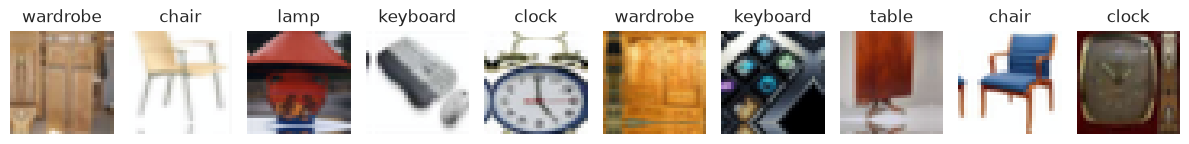


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


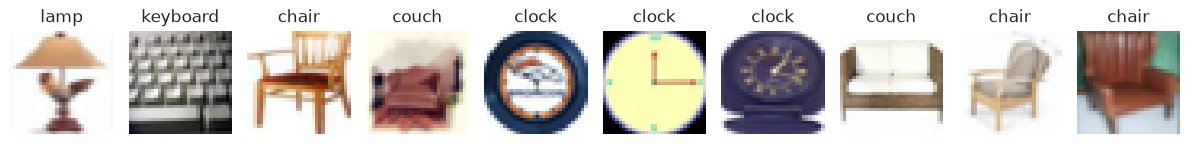

In [9]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)
    plt.close('all')  # free figure memory rather than letting it accumulate across the notebook session

### Step 3: Load the baseline model and metrics

In [10]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activati

### Step 4: Implement and evaluate compression techniques

Now you'll implement and evaluate different compression techniques. For each technique that you choose, you'll:
1. Implement the technique
2. Evaluate its impact on model size, inference time, and accuracy
3. Analyze the trade-offs

To choose a technique, simply uncomment the apply_{TECHNIQUE_NAME}_technique() function call in the corresponding technique cell block.

#### 4.1 Post-Training - Quantization

Quantization reduces the precision of weights and activations, converting floating-point values to integers.


In [11]:
# Define a function to apply quantization and evaluate results
def apply_post_training_quantization(quantization_type, backend, device):
    """
    Apply quantization to a model with given method and backend.
    
    Args:
        quantization_type: Quantization method ("static" or "dynamic")
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        device: Which device to use for model loading, training, and evaluation
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}_{backend}"
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying {quantization_type} quantization with {backend} backend")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training quantization
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER    
    quantized_model = quantize_model(
        orig_model,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=1 if quantization_type == "static" else None,  # Set this to the desired value
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply post-training quantization
## Find info at https://pytorch.org/docs/stable/quantization.html

## Experiment with different configurations
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)

Applying dynamic quantization with fbgemm backend
Applying dynamic quantization...
Model saved to ../models/post_training/quantization/dynamic_fbgemm/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 156.68it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic_fbgemm/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:08<00:00,  1.02s/it]


Confusion matrix saved to ../results/post_training/quantization/dynamic_fbgemm/confusion_matrix.png


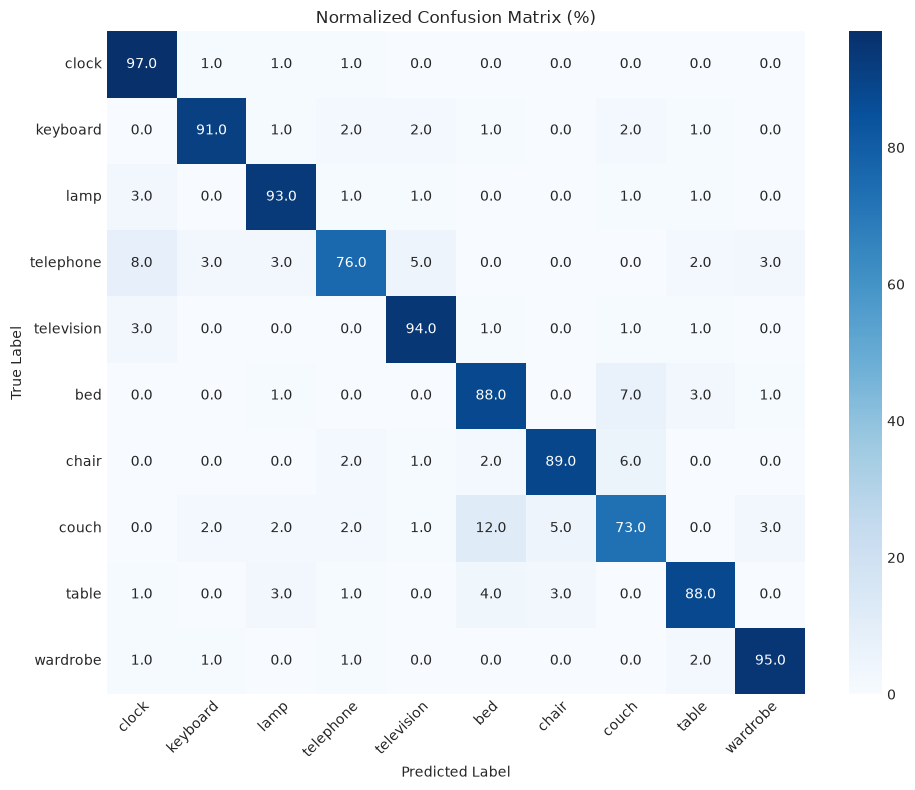


Optimized Model Metrics (post_training/quantization/dynamic_fbgemm):
Accuracy: 88.40%
Model Size: 4.24 MB
CPU Inference Time: 6.40 ms (156.14 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 204.72it/s]


Get metrics of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 139.02it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic_fbgemm/comparison.png


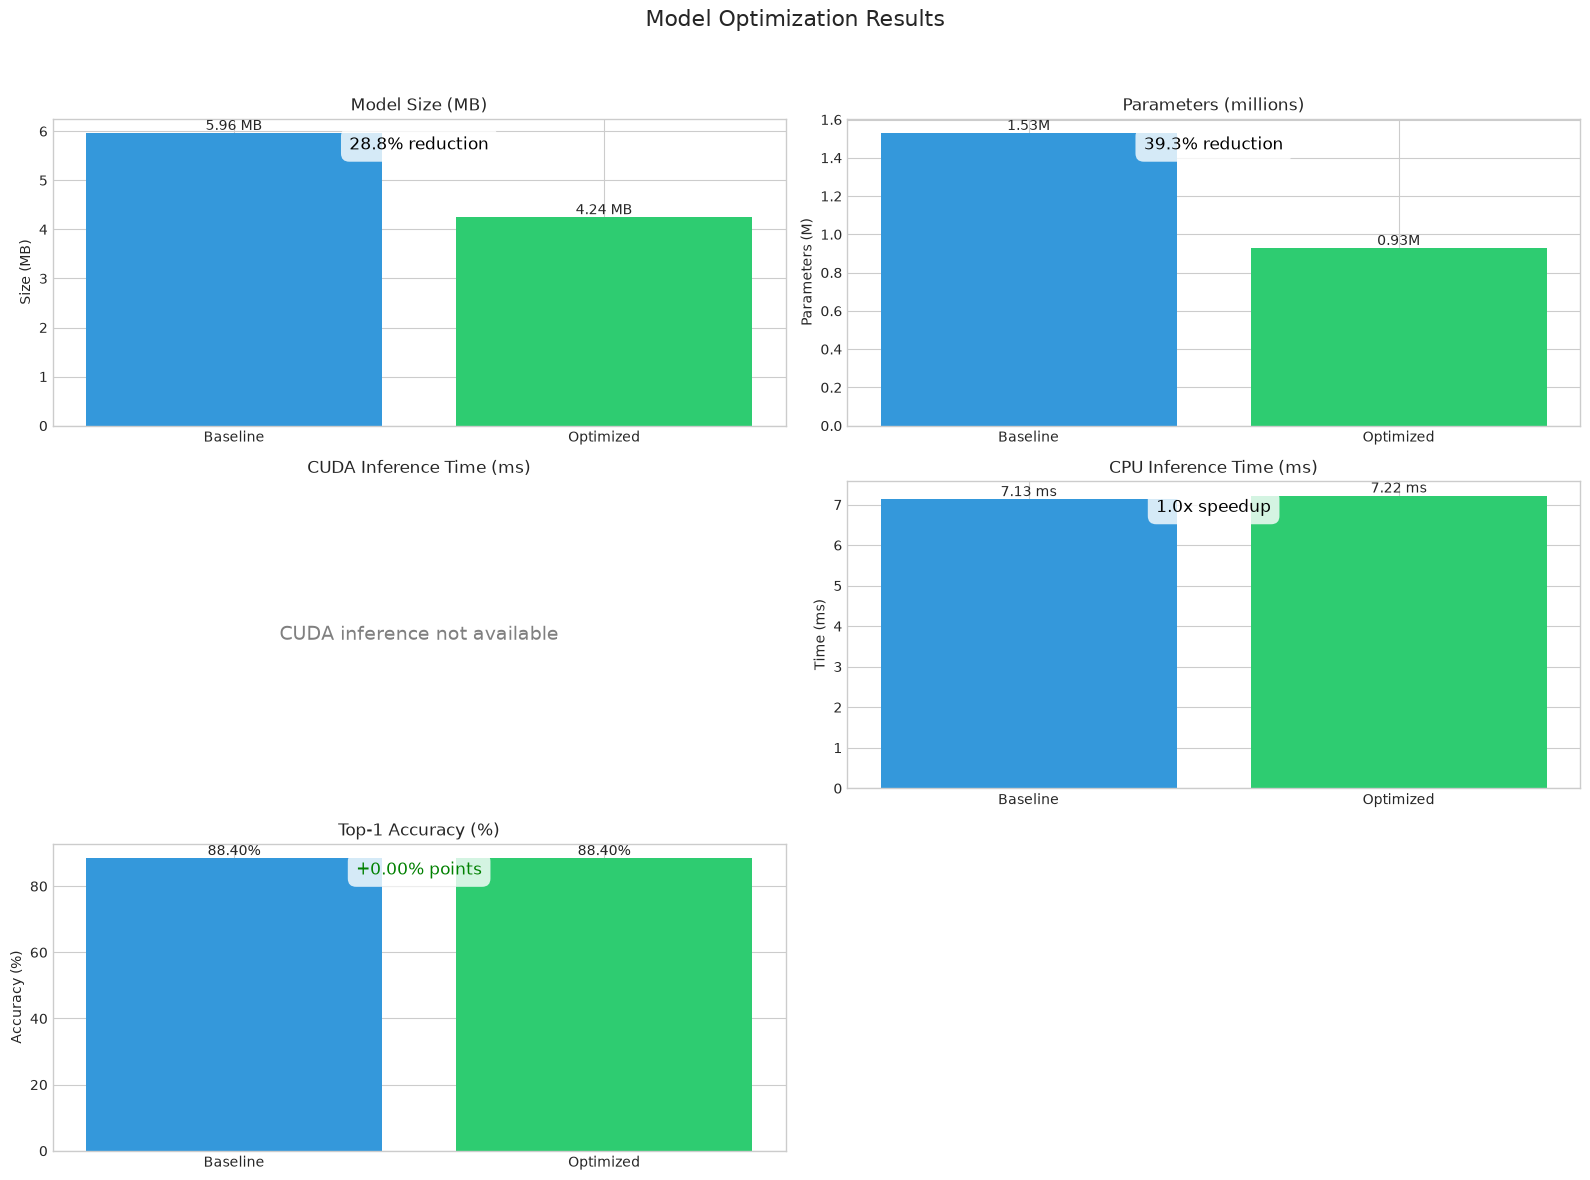


post_training/quantization/dynamic_fbgemm Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 7.22 ms (1.0x speedup)
Accuracy: 88.40% (+0.00% change)
Requirements met: False


In [12]:
quantization_type = "dynamic" # "static" # None # One of "dynamic" or "static"
backend = "fbgemm" # None  # One of "fbgemm" or "qnnpack"
device = torch.device("cpu") # None  # Define using torch.device()

# Optimize and evaluate model
quantized_model_static, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)
del quantized_model_static, quantized_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Applying dynamic quantization with qnnpack backend
Applying dynamic quantization...
Model saved to ../models/post_training/quantization/dynamic_qnnpack/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 142.57it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic_qnnpack/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:08<00:00,  1.06s/it]


Confusion matrix saved to ../results/post_training/quantization/dynamic_qnnpack/confusion_matrix.png


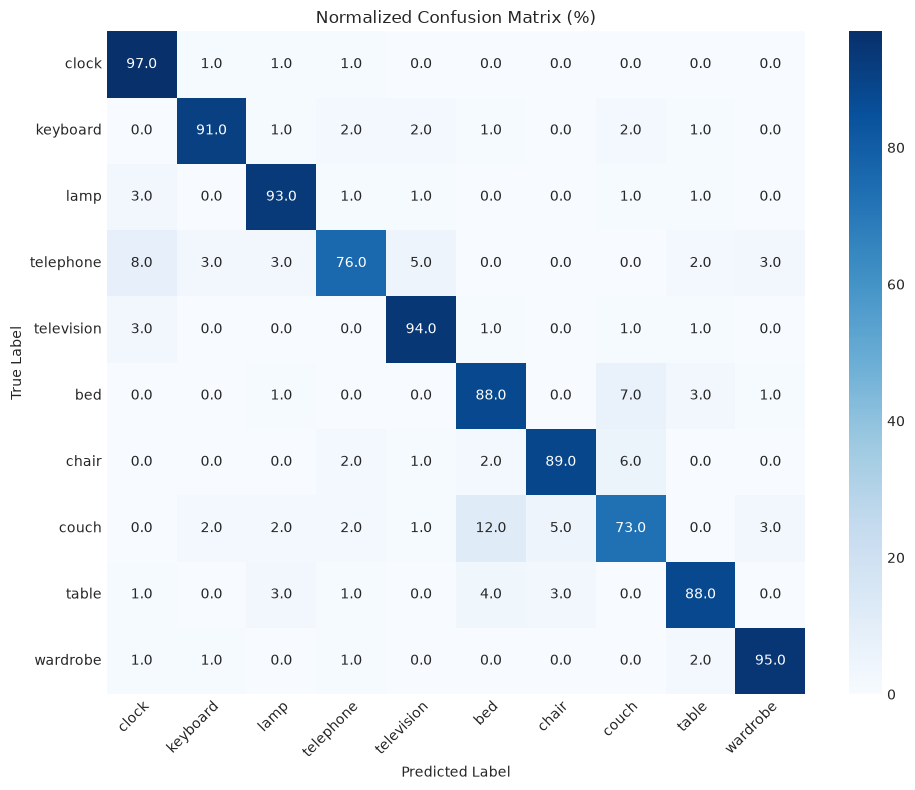


Optimized Model Metrics (post_training/quantization/dynamic_qnnpack):
Accuracy: 88.40%
Model Size: 4.24 MB
CPU Inference Time: 7.04 ms (142.12 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 191.56it/s]


Get metrics of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 123.25it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic_qnnpack/comparison.png


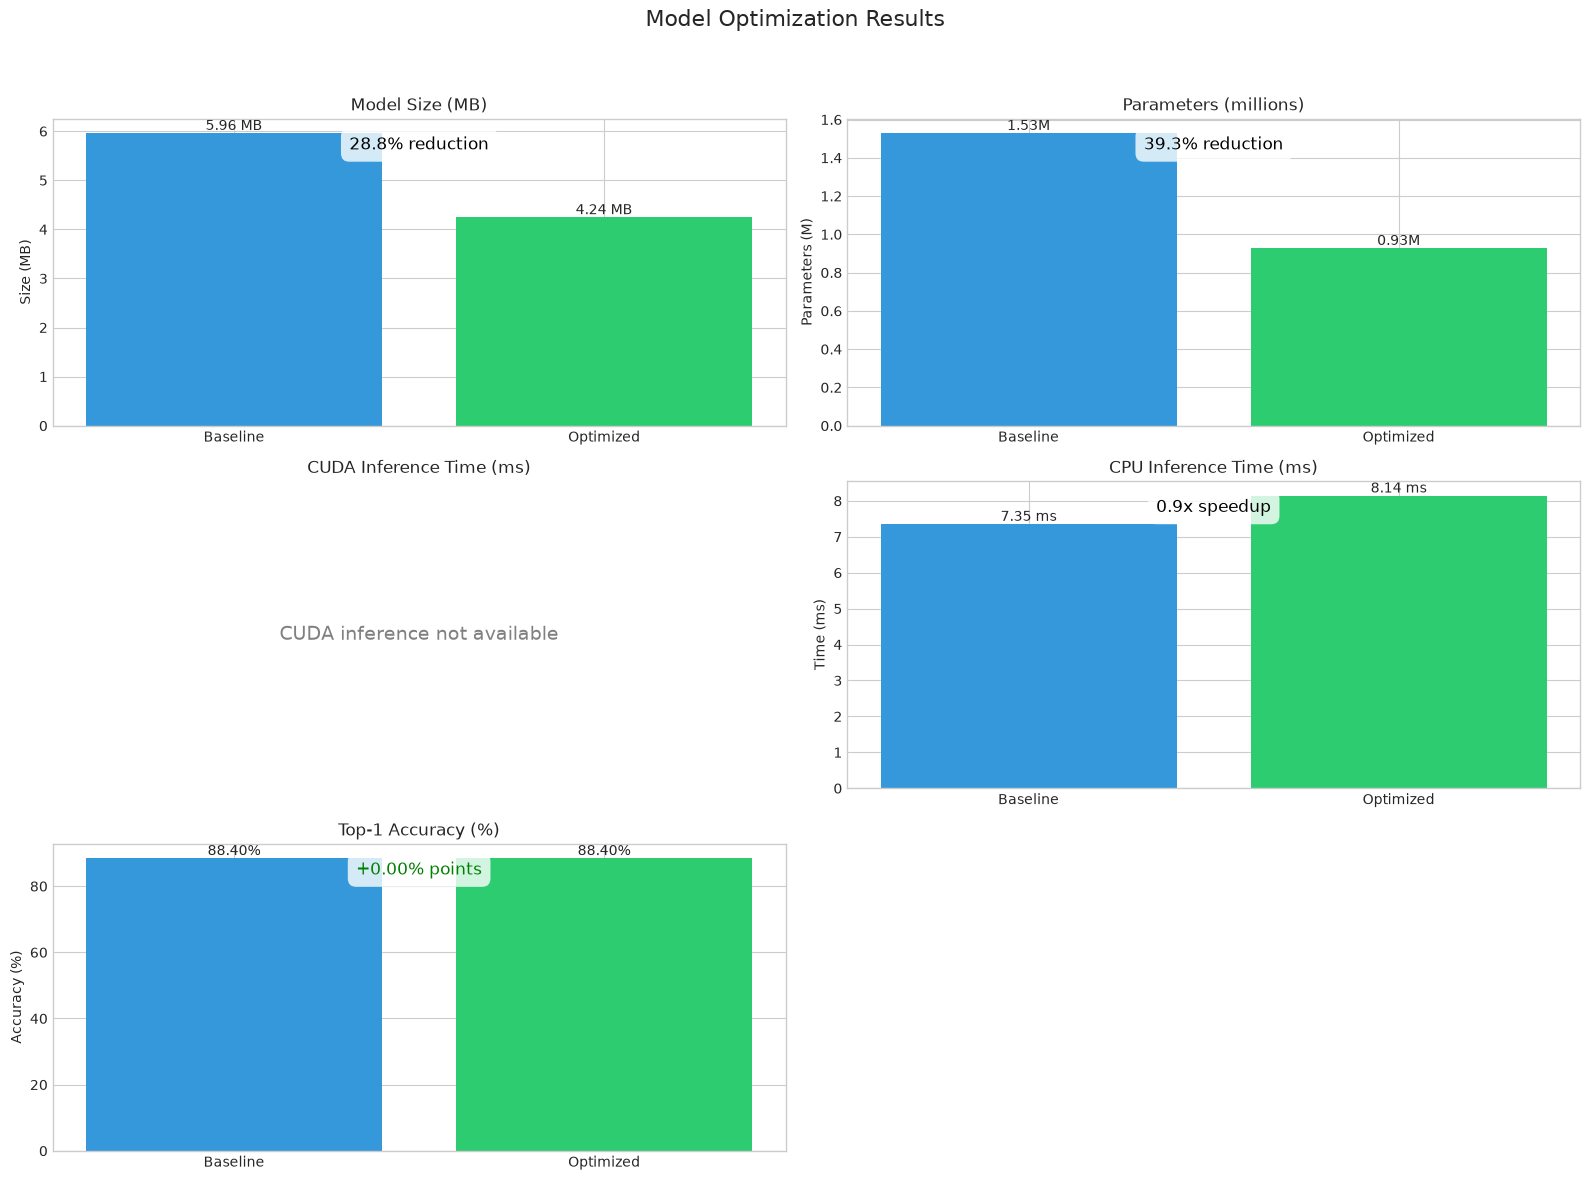


post_training/quantization/dynamic_qnnpack Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 8.14 ms (0.9x speedup)
Accuracy: 88.40% (+0.00% change)
Requirements met: False


In [13]:
quantization_type = "dynamic" # "static" # None # One of "dynamic" or "static"
backend = "qnnpack" # None  # One of "fbgemm" or "qnnpack"
device = torch.device("cpu") # None  # Define using torch.device()

# Optimize and evaluate model
quantized_model_static, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)
del quantized_model_static, quantized_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


#### 4.2 In-training - Quantization

Quantization-aware training simulates quantization during training, allowing the model to adapt to the reduced precision.

In [14]:
# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model, config, backend):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/{backend}_epochs{num_epochs}_start{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying quantization-aware training with QAT starting at epoch {qat_start_epoch} / ending at {num_epochs}")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER   
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/checkpoints",
        backend=backend,
    )

    config.pop("scheduler", None)
    config.pop("optimizer", None)
    config.pop("criterion", None)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    

    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=config["device_for_inference"],
    )

    plot_training_curves(
        qat_stats,
        title=f"QAT ({experiment_name})",
        save_path=f"../results/{experiment_name}/training_curves.png",
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=config["device_for_inference"],
    )
    
    return quantized_model, comparison_results, experiment_name

In [ ]:
#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html

## Create quantizable model version
## Check the model implementation in the `compression/` folder
model = QuantizableMobileNetV3_Household(quantize=False)
    
## Experiment with different configurations
## We recommend testing testing with various start and freeze epochs
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)

config = {
    'qat_start_epoch': 10,     # Train a few epochs in fp32 first, then switch on QAT
    'freeze_bn_epochs': 5,    # Freeze BN running stats N epochs after QAT starts
    'num_epochs': 100,
    'criterion': nn.CrossEntropyLoss(),
    'optimizer': optim.AdamW(
                    model.parameters(),
                    lr=0.001,
                    weight_decay=1e-4,
                    betas=(0.9, 0.999)
                ),
    'patience': 15,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # Quantized (int8) kernels only run on CPU, so inference/evaluation
    # of the quantized model must happen there.
    'device_for_inference': torch.device('cpu'),
    'grad_clip_norm': 1.0,
}

config['scheduler'] = optim.lr_scheduler.OneCycleLR(
            config['optimizer'],
            max_lr=0.005,  # Peak learning rate
            steps_per_epoch=len(train_loader),
            epochs=config['num_epochs'],
            pct_start=0.3,  # Spend 30% of training time warming up
            div_factor=25,  # Initial LR is max_lr/25
            final_div_factor=1000  # Final LR is max_lr/1000
        )

backend = "fbgemm" # None  # One of "fbgemm" or "qnnpack"

# Optimize and evaluate model
qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)
del qat_model, qat_comparison_results, experiment_name,  model, config
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Applying quantization-aware training with QAT starting at epoch 10 / ending at 100
Training with quantization-aware training for 100 epochs
QAT start epoch: 10, Finetune BN stats epochs: 5
QAT will be activated after epoch 10


Epoch 1/100 [Test]: 100%|██████████| 8/8 [00:04<00:00,  1.61it/s, loss=1.34, acc=59.1]


Epoch 1/100 - Train Loss: 1.7038, Train Acc: 48.22%, Test Loss: 1.1739, Test Acc: 59.10%, LR: 0.000200, Time: 13.64s


Epoch 2/100 [Test]: 100%|██████████| 8/8 [00:04<00:00,  1.63it/s, loss=1.12, acc=70.9] 


Epoch 2/100 - Train Loss: 0.8537, Train Acc: 71.72%, Test Loss: 0.8363, Test Acc: 70.90%, LR: 0.000200, Time: 13.42s


...

Epoch 34/100 [Test]: 100%|██████████| 8/8 [00:04<00:00,  1.73it/s, loss=0.889, acc=74.6]


Epoch 34/100 - Train Loss: 0.5050, Train Acc: 82.88%, Test Loss: 0.8893, Test Acc: 74.60%, LR: 0.000206, Time: 16.61s
New best quantized model! Saving... (74.60%)
Model saved to ../models/in_training/quantization/fbgemm_epochs100_start10/checkpoints


Epoch 35/100 [Test]: 100%|██████████| 8/8 [00:05<00:00,  1.51it/s, loss=0.856, acc=74.1]


Epoch 35/100 - Train Loss: 0.4605, Train Acc: 83.88%, Test Loss: 0.8556, Test Acc: 74.10%, LR: 0.000206, Time: 17.60s


Epoch 36/100 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html

## Create quantizable model version
## Check the model implementation in the `compression/` folder
model = QuantizableMobileNetV3_Household(quantize=False)
    
## Experiment with different configurations
## We recommend testing testing with various start and freeze epochs
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)

config = {
    'qat_start_epoch': 10,     # Train a few epochs in fp32 first, then switch on QAT
    'freeze_bn_epochs': 5,    # Freeze BN running stats N epochs after QAT starts
    'num_epochs': 100,
    'criterion': nn.CrossEntropyLoss(),
    'optimizer': optim.AdamW(
                    model.parameters(),
                    lr=0.001,
                    weight_decay=1e-4,
                    betas=(0.9, 0.999)
                ),
    'patience': 15,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # Quantized (int8) kernels only run on CPU, so inference/evaluation
    # of the quantized model must happen there.
    'device_for_inference': torch.device('cpu'),
    'grad_clip_norm': 1.0,
}

config['scheduler'] = optim.lr_scheduler.OneCycleLR(
            config['optimizer'],
            max_lr=0.005,  # Peak learning rate
            steps_per_epoch=len(train_loader),
            epochs=config['num_epochs'],
            pct_start=0.3,  # Spend 30% of training time warming up
            div_factor=25,  # Initial LR is max_lr/25
            final_div_factor=1000  # Final LR is max_lr/1000
        )

backend = "qnnpack" # None  # One of "fbgemm" or "qnnpack"

# Optimize and evaluate model
qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)
del qat_model, qat_comparison_results, experiment_name,  model, config
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#### 4.3 Post-training - Pruning

Pruning reduces model size by removing weights with small magnitudes that contribute less to the output.

In [ ]:
# Define a function to apply pruning and evaluate results
def apply_post_training_pruning(config):
    """
    Apply post-training pruning to a model with given pruning method and amount
    
    Args:
        config: Dictionary containing the configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    amount, pruning_method, device = config['amount'], config['pruning_method'], config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/pruning/{pruning_method}_{amount}_{device}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying post-training pruning with method {pruning_method} and amount {amount:.2f}")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training pruning
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    pruned_model = prune_model(orig_model, pruning_method, amount, config["modules_to_prune"], config["custom_pruning_fn"])

    del orig_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Save the pruned model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate pruned model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return pruned_model, comparison_results, experiment_name


# Apply post-training pruning    
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Experiment with different configurations
## We recommend testing pruning with various ratios
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)


In [ ]:
config = {
    'pruning_method': 'l1_unstructured',  # String
    'amount': 0.1,  # Float
    'modules_to_prune': None,  # (Optional) List -> None lets prune_model auto-discover Conv2d/Linear layers
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)
del pruned_model, pruned_results, experiment_name, config
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
config = {
    'pruning_method': 'l1_unstructured',  # String
    'amount': 0.3,  # Float
    'modules_to_prune': None,  # (Optional) List -> None lets prune_model auto-discover Conv2d/Linear layers
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)
del pruned_model, pruned_results, experiment_name, config
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
config = {
    'pruning_method': 'l1_unstructured',  # String
    'amount': 0.5,  # Float
    'modules_to_prune': None,  # (Optional) List -> None lets prune_model auto-discover Conv2d/Linear layers
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)
del pruned_model, pruned_results, experiment_name, config
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#### 4.4 In-training - Pruning

Gradual pruning progressively prunes weights during training, allowing the model to adapt to increasing sparsity.

In [ ]:
# Define a function to apply pruning during training and evaluate results
def apply_in_training_pruning(model, config):
    """
    Apply gradual pruning during training.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    pruning_method, initial_sparsity, final_sparsity = config['pruning_method'], config['initial_sparsity'], config['final_sparsity'] 
    start_epoch, end_epoch = config['start_epoch'], config['end_epoch'] 
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/pruning/{pruning_method}_sparsity{initial_sparsity}-{final_sparsity}_epochs{start_epoch}-{end_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying gradual pruning from {initial_sparsity:.1%} to {final_sparsity:.1%} sparsity")
    
    # Move model to specified device
    model = model.to(device)
    
    # Train with gradual pruning
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    pruned_model, pruning_stats, pruned_best_accuracy, pruned_best_epoch = train_with_pruning(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(pruning_stats, f, indent=4)
    
    # Save the quantized model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=pruning_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    return pruned_model, comparison_results, experiment_name



In [ ]:
# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## Experiment with different configurations
# We recommend testing pruning with various sparsity and epochs settings
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
num_epochs = 100

config = {
    # General training config
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss  
    'optimizer': optim.AdamW(
                model.parameters(),
                lr=0.001,
                weight_decay=1e-4,
                betas=(0.9, 0.999)
            ),  # A PyTorch optimizer
    'patience': 15,  # Integer
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
    # Pruning-specific config
    'initial_sparsity': 0.0,    # Float
    'final_sparsity': 0.3,      # Float
    'start_epoch': 10,           # Integer -- let the model warm up in fp-dense form first
    'end_epoch': num_epochs - 16,  # Integer -- leave a fine-tuning tail after pruning ends
    'pruning_frequency': 4,     # Integer -- re-prune every N epochs within the window
    'pruning_method': 'global_unstructured',  # String
    'schedule_type': 'cubic',   # String
    'only_prune_conv': False,   # Boolean
}

config['scheduler'] = optim.lr_scheduler.OneCycleLR(
            config['optimizer'],
            max_lr=0.005,  # Peak learning rate
            steps_per_epoch=len(train_loader),
            epochs=num_epochs,
            pct_start=0.3,  # Spend 30% of training time warming up
            div_factor=25,  # Initial LR is max_lr/25
            final_div_factor=1000  # Final LR is max_lr/1000
        )
            
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

del model, config, pruned_model, pruned_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## Experiment with different configurations
# We recommend testing pruning with various sparsity and epochs settings
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
num_epochs = 100

config = {
    # General training config
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss  
    'optimizer': optim.AdamW(
                model.parameters(),
                lr=0.001,
                weight_decay=1e-4,
                betas=(0.9, 0.999)
            ),  # A PyTorch optimizer
    'patience': 15,  # Integer
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
    # Pruning-specific config
    'initial_sparsity': 0.0,    # Float
    'final_sparsity': 0.5,      # Float
    'start_epoch': 10,           # Integer -- let the model warm up in fp-dense form first
    'end_epoch': num_epochs - 16,  # Integer -- leave a fine-tuning tail after pruning ends
    'pruning_frequency': 4,     # Integer -- re-prune every N epochs within the window
    'pruning_method': 'global_unstructured',  # String
    'schedule_type': 'cubic',   # String
    'only_prune_conv': False,   # Boolean
}

config['scheduler'] = optim.lr_scheduler.OneCycleLR(
            config['optimizer'],
            max_lr=0.005,  # Peak learning rate
            steps_per_epoch=len(train_loader),
            epochs=num_epochs,
            pct_start=0.3,  # Spend 30% of training time warming up
            div_factor=25,  # Initial LR is max_lr/25
            final_div_factor=1000  # Final LR is max_lr/1000
        )
            
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

del model, config, pruned_model, pruned_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## Experiment with different configurations
# We recommend testing pruning with various sparsity and epochs settings
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
num_epochs = 100

config = {
    # General training config
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss  
    'optimizer': optim.AdamW(
                model.parameters(),
                lr=0.001,
                weight_decay=1e-4,
                betas=(0.9, 0.999)
            ),  # A PyTorch optimizer
    'patience': 15,  # Integer
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
    # Pruning-specific config
    'initial_sparsity': 0.0,    # Float
    'final_sparsity': 0.7,      # Float
    'start_epoch': 10,           # Integer -- let the model warm up in fp-dense form first
    'end_epoch': num_epochs - 16,  # Integer -- leave a fine-tuning tail after pruning ends
    'pruning_frequency': 4,     # Integer -- re-prune every N epochs within the window
    'pruning_method': 'global_unstructured',  # String
    'schedule_type': 'cubic',   # String
    'only_prune_conv': False,   # Boolean
}

config['scheduler'] = optim.lr_scheduler.OneCycleLR(
            config['optimizer'],
            max_lr=0.005,  # Peak learning rate
            steps_per_epoch=len(train_loader),
            epochs=num_epochs,
            pct_start=0.3,  # Spend 30% of training time warming up
            div_factor=25,  # Initial LR is max_lr/25
            final_div_factor=1000  # Final LR is max_lr/1000
        )
            
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

del model, config, pruned_model, pruned_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#### 4.5 In-training - Knowledge Distillation

Knowledge distillation trains a smaller student model to mimic a larger teacher model.

In [ ]:
# Define a function to apply knowledge distillation and evaluate results
def apply_knowledge_distillation(teacher_model, student_model, config):
    """
    Apply knowledge distillation from a teacher model to a student model.
    
    Args:
        teacher_model: Pre-trained teacher model
        student_model: Smaller student model to train
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (distilled_student_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )

    config.pop("scheduler", None)
    config.pop("optimizer", None)
    config.pop("criterion", None)
    del teacher_model, student_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, comparison_results, experiment_name

In [ ]:
# Apply knowledge distillation
## Find more info at https://pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html

## Load the pre-trained teacher model
teacher_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth")
teacher_model.eval()  # Teacher should be in eval mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
## Create student model
## Check the model implementation in the `compression/` folder
student_model = MobileNetV3_Household_Small(num_classes=len(class_names))
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

# EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
# We recommend testing distillation with different alpha and temperature
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)


optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)
num_epochs=1000
config = {
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.OneCycleLR(
                    optimizer,
                    max_lr=0.005,  # Peak learning rate
                    steps_per_epoch=len(train_loader),
                    epochs=num_epochs,
                    pct_start=0.3,  # Spend 30% of training time warming up
                    div_factor=25,  # Initial LR is max_lr/25
                    final_div_factor=1000  # Final LR is max_lr/1000
                ),  # A PyTorch scheduler
    'alpha': 0.3,  # Float
    'temperature': 4.0,  # Float
    'patience': 10,  # Integer
    'device': device,  # Define with torch.device()
    'grad_clip_norm':1.0,
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

del distilled_model, distilled_comparison_metrics, experiment_name, config, student_model, optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
## Create student model
## Check the model implementation in the `compression/` folder
student_model = MobileNetV3_Household_Small(num_classes=len(class_names))
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

# EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
# We recommend testing distillation with different alpha and temperature
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)


optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)
num_epochs=1000
config = {
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.OneCycleLR(
                    optimizer,
                    max_lr=0.005,  # Peak learning rate
                    steps_per_epoch=len(train_loader),
                    epochs=num_epochs,
                    pct_start=0.3,  # Spend 30% of training time warming up
                    div_factor=25,  # Initial LR is max_lr/25
                    final_div_factor=1000  # Final LR is max_lr/1000
                ),  # A PyTorch scheduler
    'alpha': 0.3,  # Float
    'temperature': 10.0,  # Float
    'patience': 10,  # Integer
    'device': device,  # Define with torch.device()
    'grad_clip_norm':1.0,
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

del distilled_model, distilled_comparison_metrics, experiment_name, config, student_model, optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
## Create student model
## Check the model implementation in the `compression/` folder
student_model = MobileNetV3_Household_Small(num_classes=len(class_names))
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

# EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
# We recommend testing distillation with different alpha and temperature
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)


optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)
num_epochs=1000
config = {
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.OneCycleLR(
                    optimizer,
                    max_lr=0.005,  # Peak learning rate
                    steps_per_epoch=len(train_loader),
                    epochs=num_epochs,
                    pct_start=0.3,  # Spend 30% of training time warming up
                    div_factor=25,  # Initial LR is max_lr/25
                    final_div_factor=1000  # Final LR is max_lr/1000
                ),  # A PyTorch scheduler
    'alpha': 0.5,  # Float
    'temperature': 1.0,  # Float
    'patience': 10,  # Integer
    'device': device,  # Define with torch.device()
    'grad_clip_norm':1.0,
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

del distilled_model, distilled_comparison_metrics, experiment_name, config, student_model, optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
## Create student model
## Check the model implementation in the `compression/` folder
student_model = MobileNetV3_Household_Small(num_classes=len(class_names))
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

# EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
# We recommend testing distillation with different alpha and temperature
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)


optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)
num_epochs=1000
config = {
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.OneCycleLR(
                    optimizer,
                    max_lr=0.005,  # Peak learning rate
                    steps_per_epoch=len(train_loader),
                    epochs=num_epochs,
                    pct_start=0.3,  # Spend 30% of training time warming up
                    div_factor=25,  # Initial LR is max_lr/25
                    final_div_factor=1000  # Final LR is max_lr/1000
                ),  # A PyTorch scheduler
    'alpha': 0.1,  # Float
    'temperature': 5.0,  # Float
    'patience': 10,  # Integer
    'device': device,  # Define with torch.device()
    'grad_clip_norm':1.0,
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

del distilled_model, distilled_comparison_metrics, experiment_name, config, student_model, optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
del teacher_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#### 4.6 In-training - Graph Optimizations

Graph optimizations fuse operations and remove redundant nodes for better inference performance.

In [ ]:
# Define a function to apply graph optimization and evaluate results
def apply_graph_optimization(optimization_method, input_shape=(1, 3, 32, 32), device=torch.device('cpu')):
    """
    Apply graph optimization to a model.
    
    Args:
        optimization_method: Optimization method to use in ["torchscript", "torch_fx"]
        input_shape: Shape of input tensor
        device: Which device to optimize the model on
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    
    # Apply graph optimization
    # IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"
    save_model(optimized_model, f"../models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
    assert is_equivalent, "Optimized model is not equivalent to the original model!"

    del orig_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return optimized_model, comparison_results, experiment_name

# Apply graph optimization
## Find info at https://pytorch.org/docs/stable/fx.html and https://pytorch.org/docs/stable/jit.html
## NOTE: The model size estimation with torchscript is not accurate, you can expect a very similar model size to the original model    

## EXPERIMENT WITH DIFFERENT  PARAMETERS
## We recommend testing testing with both optimization methods and device types
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)

In [ ]:
optimization_method = "torchscript"  # One of "torch_fx" or "torchscript"
device = torch.device('cpu')  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)
del graph_optimized_model, graph_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
optimization_method = "torchscript"  # One of "torch_fx" or "torchscript"
device = torch.device('cuda')  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)
del graph_optimized_model, graph_comparison_results, experiment_name
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Step 5: Compare All Techniques

Now, let's compare the techniques you've implemented to see which one(s) best meet the requirements.

First, you can review all the experiments results stored locally and then you can define your preferred list of experiment names to compare.

In [ ]:
# Check all experiments you've run to completion
list_experiments()

In [ ]:
# Define the list of experiments to compare
experiments_to_load_from_disk = list_experiments()
experiments_to_load_from_memory = None

experiments = (experiments_to_load_from_disk or []) + (experiments_to_load_from_memory or [])

In [ ]:
# Or with a mix of pre-loaded and disk-based results
_ = compare_experiments(
    experiments=experiments,
    baseline_metrics=baseline_metrics
)

In [ ]:
# Visual comparison of baseline + all techniques using plot_multiple_models_comparison()
# (imported in the setup cell but not yet used anywhere in this notebook)

# Build the {model_name: metrics_dict} mapping this function expects, by
# combining the in-memory baseline_metrics with every experiment's saved
# metrics.json from disk (the same experiments listed/compared above).
models_data = {"Baseline": baseline_metrics}

for exp_name in experiments:
    metrics_path = f"../results/{exp_name}/metrics.json"
    try:
        with open(metrics_path, "r") as f:
            models_data[exp_name] = json.load(f)
    except FileNotFoundError:
        print(f"Skipping {exp_name}: no metrics.json found at {metrics_path}")

_ = plot_multiple_models_comparison(
    models_data,
    metrics=["accuracy", "size", "cpu_inference_time", "parameters"],
    output_path="../results/all_techniques_comparison.png",
    normalize=False,  # show actual values (MB, ms, %, M params) rather than normalized scores
)


--------

**TODO: Analyze compression results and collect considerations on combining techniques for the multi-step pipeline**

After implementing and testing various compression techniques, analyze your experimental results to identify the most effective approaches for the UdaciSense application.

Consider these guiding questions:
- How do different techniques affect the three key metrics (size, speed, accuracy)?
- What technique-specific challenges or insights did you discover?
- Which techniques show complementary strengths and weaknesses?
- How could combining these techniques meet all CTO requirements?

Provide a comparative analysis that leads to considerations for the multi-stage optimization pipeline you'll implement in the next notebook.

## Compression Techniques Analysis for UdaciSense Object Recognition Model

*(Replace this with your analysis)*

> 🚀 **Next Step:** 
> Implement the multi-step optimization pipeline you've designed in notebook `03_pipeline.ipynb`  